# Exploratory Data Analysis

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [55]:
df=pd.read_csv('2-orders-data.csv')

In [3]:
df.head(5)

,USER_ID,ORDER_ID,PURCHASE_TS,SHIP_TS,PRODUCT_NAME,PRODUCT_ID,USD_PRICE,PURCHASE_PLATFORM,MARKETING_CHANNEL,ACCOUNT_CREATION_METHOD,COUNTRY_CODE,Unnamed: 11,Unnamed: 12
0,2c06175e,0001328c3c220830,24-12-2020,13-12-2020,Nintendo Switch,e682,168.00,website,affiliate,unknown,US,NaN,NaN
1,ee8e5bc2,0002af7a5c6100772,01-10-2020,21-09-2020,Nintendo Switch,e682,160.61,website,direct,desktop,DE,NaN,NaN
2,9eb4efe0,0002b8350e167074,21-04-2020,16-02-2020,Nintendo Switch,8d0d,151.20,website,direct,desktop,US,NaN,NaN
3,cac7cbaf,0006d06b98385729,07-04-2020,04-04-2020,Sony PlayStation 5 Bundle,54ed,1132.82,website,direct,desktop,AU,NaN,NaN
4,6b0230bc,00097279a2f46150,24-11-2020,02-08-2020,Nintendo Switch,8d0d,33.89,website,direct,desktop,TR,NaN,NaN


In [4]:
df.shape

(21864, 13)

#### Dataset Info

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21864 entries, 0 to 21863
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   USER_ID                  21864 non-null  object 
 1   ORDER_ID                 21864 non-null  object 
 2   PURCHASE_TS              21864 non-null  object 
 3   SHIP_TS                  21864 non-null  object 
 4   PRODUCT_NAME             21864 non-null  object 
 5   PRODUCT_ID               21864 non-null  object 
 6   USD_PRICE                21859 non-null  float64
 7   PURCHASE_PLATFORM        21864 non-null  object 
 8   MARKETING_CHANNEL        21781 non-null  object 
 9   ACCOUNT_CREATION_METHOD  21781 non-null  object 
 10  COUNTRY_CODE             21826 non-null  object 
 11  Unnamed: 11              0 non-null      float64
 12  Unnamed: 12              0 non-null      float64
dtypes: float64(3), object(10)
memory usage: 2.2+ MB


#### Data Types

In [6]:
df.dtypes

USER_ID                     object
ORDER_ID                    object
PURCHASE_TS                 object
SHIP_TS                     object
PRODUCT_NAME                object
PRODUCT_ID                  object
USD_PRICE                  float64
PURCHASE_PLATFORM           object
MARKETING_CHANNEL           object
ACCOUNT_CREATION_METHOD     object
COUNTRY_CODE                object
Unnamed: 11                float64
Unnamed: 12                float64
dtype: object

#### Standardise Column Names

In [7]:
df.columns=df.columns.str.lower()
df.columns

Index(['user_id', 'order_id', 'purchase_ts', 'ship_ts', 'product_name',
       'product_id', 'usd_price', 'purchase_platform', 'marketing_channel',
       'account_creation_method', 'country_code', 'unnamed: 11',
       'unnamed: 12'],
      dtype='object')

#### Statistical Summary

In [8]:
df.describe()

,usd_price,unnamed: 11,unnamed: 12
count,21859.000000,0.0,0.0
mean,281.406583,NaN,NaN
std,366.296410,NaN,NaN
min,0.000000,NaN,NaN
25%,126.000000,NaN,NaN
50%,168.000000,NaN,NaN
75%,357.000000,NaN,NaN
max,3146.880000,NaN,NaN


### Data Cleaning

#### Check Missing Values

In [9]:
#8.Checking for missing values (NaN values) & replace with mean.
df.isna().sum()

user_id                        0
order_id                       0
purchase_ts                    0
ship_ts                        0
product_name                   0
product_id                     0
usd_price                      5
purchase_platform              0
marketing_channel             83
account_creation_method       83
country_code                  38
unnamed: 11                21864
unnamed: 12                21864
dtype: int64

In [10]:
mean=df['marketing_channel'].mode()
print('most repeated values:',mean)

most repeated values: 0    direct
Name: marketing_channel, dtype: object


In [11]:
df['marketing_channel']=df['marketing_channel'].fillna('direct')

In [12]:
df['marketing_channel'].isnull().sum()

np.int64(0)

In [13]:
df['usd_price']=df['usd_price'].fillna(df['usd_price'].mean())

In [14]:
df['usd_price'].isnull().sum()

np.int64(0)

In [15]:
df['account_creation_method']=df['account_creation_method'].fillna('unknown')

In [16]:
df[df['country_code'].isna()]

,user_id,order_id,purchase_ts,ship_ts,product_name,product_id,usd_price,purchase_platform,marketing_channel,account_creation_method,country_code,unnamed: 11,unnamed: 12
526,6af1d816,06ee8b82fbc46119,12-04-2019,12-12-2018,JBL Quantum 100 Gaming Headset,8315,24.30,mobile app,affiliate,unknown,NaN,NaN,NaN
671,2ad6743f,08feac8f0a020345,16-04-2020,07-12-2019,JBL Quantum 100 Gaming Headset,8315,22.98,mobile app,affiliate,unknown,NaN,NaN,NaN
1043,7a4a13ce,0dc92d0562552247,13-05-2020,23-02-2020,Nintendo Switch,8e5d,157.42,mobile app,affiliate,unknown,NaN,NaN,NaN
3585,9cef5a34,2fa5682923166358,22-04-2020,25-04-2020,Nintendo Switch,8e5d,161.02,mobile app,direct,desktop,NaN,NaN,NaN
4083,e5d4f232,360891064a397089,27-09-2020,29-09-2020,Nintendo Switch,8e5d,165.30,mobile app,affiliate,unknown,NaN,NaN,NaN
4084,e5d4f232,360891064a397090,27-09-2020,29-09-2020,Nintendo Switch,8e5d,165.30,mobile app,affiliate,unknown,NaN,NaN,NaN
4875,4552ac90,4054d07e48c31128,27-07-2020,30-07-2020,Nintendo Switch,8e5d,163.04,mobile app,affiliate,unknown,NaN,NaN,NaN
5144,b26a797c,43ce0b4a8fe75579,30-03-2019,01-04-2019,Nintendo Switch,b5f7,85.11,mobile app,affiliate,unknown,NaN,NaN,NaN
6124,42edad8a,50e43de8ab930156,19-12-2020,22-12-2020,JBL Quantum 100 Gaming Headset,4c58,24.50,mobile app,affiliate,unknown,NaN,NaN,NaN
6125,42edad8a,50e43de8ab930157,19-12-2020,22-12-2020,JBL Quantum 100 Gaming Headset,4c58,24.50,mobile app,affiliate,unknown,NaN,NaN,NaN


In [17]:
df['country_code']=df['country_code'].fillna('Not available')

#### Verify All Nulls Handled

In [18]:
df.isnull().sum()

user_id                        0
order_id                       0
purchase_ts                    0
ship_ts                        0
product_name                   0
product_id                     0
usd_price                      0
purchase_platform              0
marketing_channel              0
account_creation_method        0
country_code                   0
unnamed: 11                21864
unnamed: 12                21864
dtype: int64

#### Drop Unnamed Columns

In [19]:
df.drop(columns='unnamed: 11',inplace=True)

In [20]:
df.drop(columns='unnamed: 12',inplace=True)

#### Check and Remove Duplicates

In [57]:
df[df.duplicated()].count()

USER_ID                    35
ORDER_ID                   35
PURCHASE_TS                35
SHIP_TS                    35
PRODUCT_NAME               35
PRODUCT_ID                 35
USD_PRICE                  35
PURCHASE_PLATFORM          35
MARKETING_CHANNEL          35
ACCOUNT_CREATION_METHOD    35
COUNTRY_CODE               35
Unnamed: 11                 0
Unnamed: 12                 0
dtype: int64

In [22]:
df.drop_duplicates(inplace=True)

In [23]:
df.duplicated().sum()

np.int64(0)

## Data Type Conversion

In [24]:
df.dtypes

user_id                     object
order_id                    object
purchase_ts                 object
ship_ts                     object
product_name                object
product_id                  object
usd_price                  float64
purchase_platform           object
marketing_channel           object
account_creation_method     object
country_code                object
dtype: object

#### Rename Columns

In [25]:
df.rename(columns={'purchase_ts':'purchase_date','ship_ts':'ship_date','usd_price':'price'},inplace=True)
df.columns

Index(['user_id', 'order_id', 'purchase_date', 'ship_date', 'product_name',
       'product_id', 'price', 'purchase_platform', 'marketing_channel',
       'account_creation_method', 'country_code'],
      dtype='object')

#### Convert purchase_date to datetime

In [26]:
df['purchase_date']=df['purchase_date'].str.strip()

In [27]:
df[['purchase_date','time']]=df['purchase_date'].str.split(" ",expand=True)

In [28]:
df['purchase_date']=df['purchase_date'].replace([None],np.nan)

In [29]:
df[df['purchase_date'].isnull()]

,user_id,order_id,purchase_date,ship_date,product_name,product_id,price,purchase_platform,marketing_channel,account_creation_method,country_code,time


In [30]:
df.isnull().sum()

user_id                        0
order_id                       0
purchase_date                  0
ship_date                      0
product_name                   0
product_id                     0
price                          0
purchase_platform              0
marketing_channel              0
account_creation_method        0
country_code                   0
time                       21819
dtype: int64

In [31]:
df['purchase_date']=df['purchase_date'].fillna('05-07-2019')

In [32]:
df['purchase_date']=pd.to_datetime(df['purchase_date'],format='mixed',dayfirst=True)

In [33]:
df[df['purchase_date'].isnull()]

,user_id,order_id,purchase_date,ship_date,product_name,product_id,price,purchase_platform,marketing_channel,account_creation_method,country_code,time
1047,a5298a4d,0dda212aaea69940,NaT,08-07-2019,JBL Quantum 100 Gaming Headset,ab0f,21.96,website,direct,desktop,FR,None


In [34]:
df.drop(columns='time',inplace=True)

In [35]:
df['ship_date']=df['ship_date'].str.strip()

In [36]:
df['ship_date']=pd.to_datetime(df['ship_date'],format='mixed',dayfirst=True)

#### Verify Data Types

In [37]:
df.dtypes

user_id                            object
order_id                           object
purchase_date              datetime64[ns]
ship_date                  datetime64[ns]
product_name                       object
product_id                         object
price                             float64
purchase_platform                  object
marketing_channel                  object
account_creation_method            object
country_code                       object
dtype: object

## Feature Engineering

date column define the object dataype ,
change datatype object to date and extract month,year,week and create new column

In [38]:
df['months']=df['purchase_date'].dt.month

In [39]:
df['year']=df['purchase_date'].dt.year
df['weeks']=df['purchase_date'].dt.isocalendar().week

In [40]:
df['year'].unique()

array([2020., 2019.,   nan, 2021.])

In [41]:
df['months'].unique()

array([12., 10.,  4., 11.,  8.,  5.,  7.,  3.,  2.,  9.,  6.,  1., nan])

In [42]:
df['ship_year']=df['ship_date'].dt.year

In [43]:
df.isnull().sum()

user_id                    0
order_id                   0
purchase_date              1
ship_date                  0
product_name               0
product_id                 0
price                      0
purchase_platform          0
marketing_channel          0
account_creation_method    0
country_code               0
months                     1
year                       1
weeks                      1
ship_year                  0
dtype: int64

In [44]:
df.dtypes

user_id                            object
order_id                           object
purchase_date              datetime64[ns]
ship_date                  datetime64[ns]
product_name                       object
product_id                         object
price                             float64
purchase_platform                  object
marketing_channel                  object
account_creation_method            object
country_code                       object
months                            float64
year                              float64
weeks                              UInt32
ship_year                           int32
dtype: object

In [45]:
df.head(2)

,user_id,order_id,purchase_date,ship_date,product_name,product_id,price,purchase_platform,marketing_channel,account_creation_method,country_code,months,year,weeks,ship_year
0,2c06175e,0001328c3c220830,2020-12-24,2020-12-13,Nintendo Switch,e682,168.00,website,affiliate,unknown,US,12.0,2020.0,52,2020
1,ee8e5bc2,0002af7a5c6100772,2020-10-01,2020-09-21,Nintendo Switch,e682,160.61,website,direct,desktop,DE,10.0,2020.0,40,2020


## Data Visualization

####  Product-wise Revenue

Text(0.5, 1.0, 'product wise revenue')

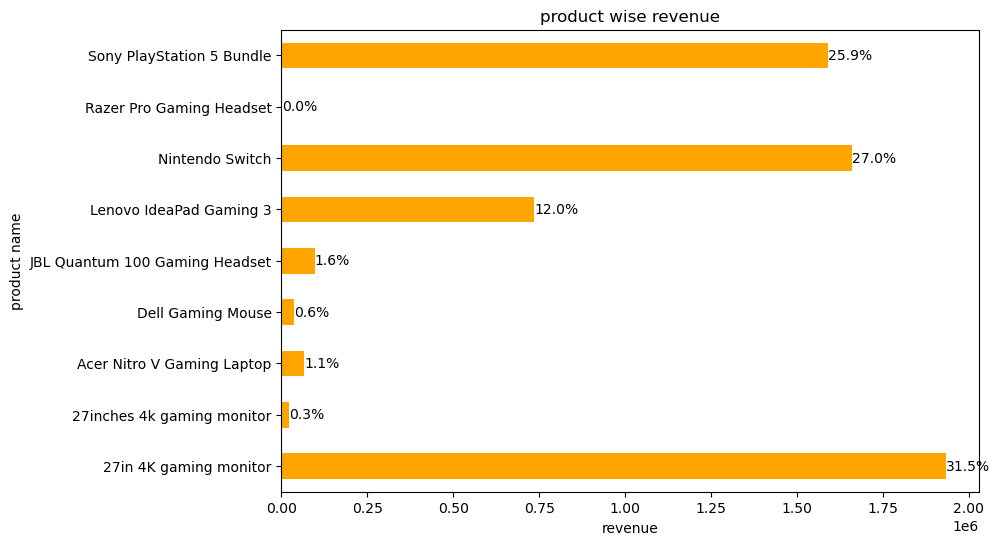

In [46]:
plt.figure(figsize=(9,6))
product_wise=df.groupby('product_name')['price'].sum()
product_wise.plot(kind='barh',color='orange')

percentage=(product_wise / product_wise.sum())*100
for i, value in enumerate(product_wise):
    pct = percentage.iloc[i]
    plt.text(value, i, f'{pct:.1f}%', va='center')
plt.xlabel('revenue')
plt.ylabel('product name')
plt.title('product wise revenue')

#### Orders by Marketing Channel

Text(0.5, 1.0, 'channel vs orders')

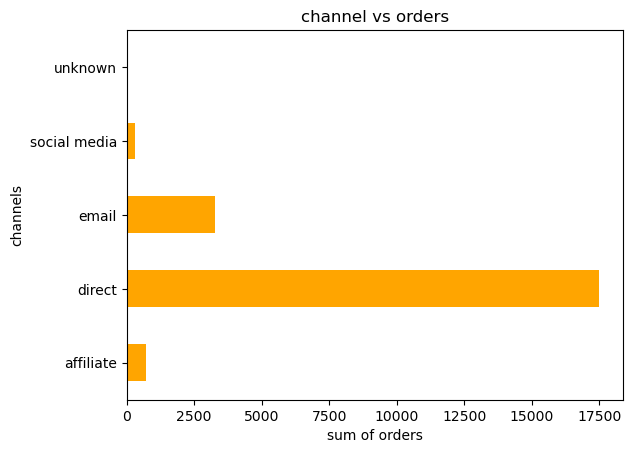

In [47]:
marketing=df.groupby('marketing_channel')['order_id'].count()
marketing.plot(kind='barh',color='orange')
plt.xlabel('sum of orders')
plt.ylabel('channels')
plt.title('channel vs orders')

#### Weekly Order Trend

In [48]:
df['weeks'].unique()

<IntegerArray>
[  52,   40,   17,   15,   48,   34,   20,   27,   12,   44,   50,   35,    7,
   42,   43,   21,   49,   14,   36,   26,   38,   19,   25,   24,   33,    5,
   39,   23,   37,   13,   29,   51,   47,   28,   18,    8,   32,   30,   45,
   46,    4,   31,    9,   53,   11,   41,   22,    6,   10,   16, <NA>,    1,
    3,    2]
Length: 54, dtype: UInt32

Text(0.5, 1.0, 'orders trend by weeks')

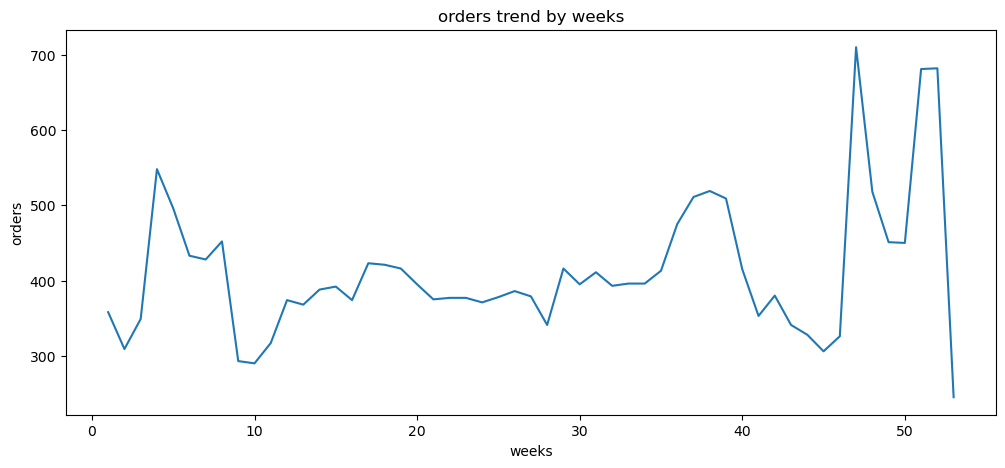

In [49]:
#3.Design Weekly Patterns in Oders Shipped (2019 - 2021).
months=df.groupby('weeks')['order_id'].count()
months
plt.figure(figsize=(12,5))
months.plot(kind='line')
plt.xlabel('weeks')
plt.ylabel('orders')
plt.title('orders trend by weeks')

#### Yearly Order Volume

In [50]:
df['year'].unique()

array([2020., 2019.,   nan, 2021.])

Text(0.5, 1.0, 'orders by year')

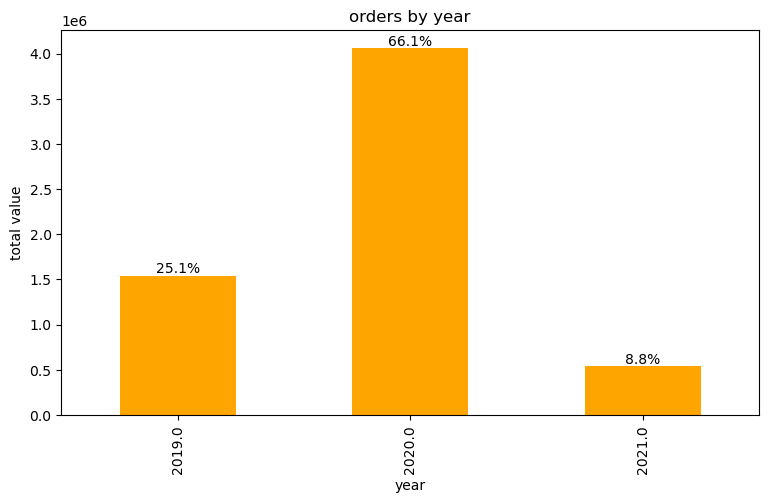

In [51]:
#Design Yearly Order Volume Trends
year=df.groupby('year')['price'].sum()
year
plt.figure(figsize=(9,5))
year.plot(kind='bar',color='orange')
percent = (year / year.sum()) * 100
for i, value in enumerate(year):
    pct=percent.iloc[i]
    plt.text(i,value,f'{pct:.1f}%', ha='center',va='bottom')
plt.xlabel('year')
plt.ylabel('total value')
plt.title('orders by year')

#### Orders Shipped by Year

Text(0.5, 1.0, 'orders shipped by year')

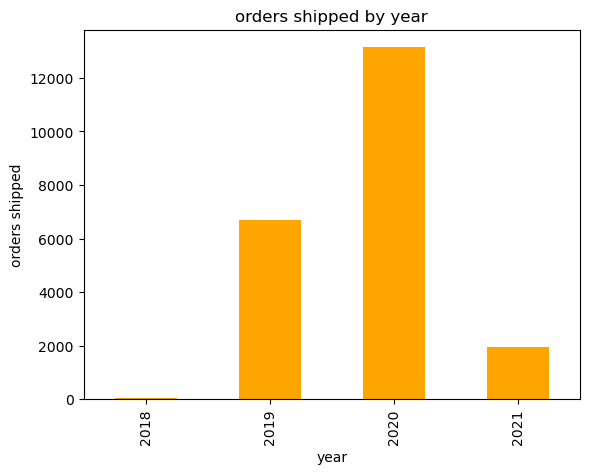

In [52]:
#5.Design Orders Shipped by Year.
shipped=df.groupby('ship_year')['order_id'].count()
shipped.plot(kind='bar',color='orange')
plt.xlabel('year')
plt.ylabel('orders shipped')
plt.title('orders shipped by year')

#### Correlation Heatmap

In [53]:
relation=df.corr(numeric_only=True)

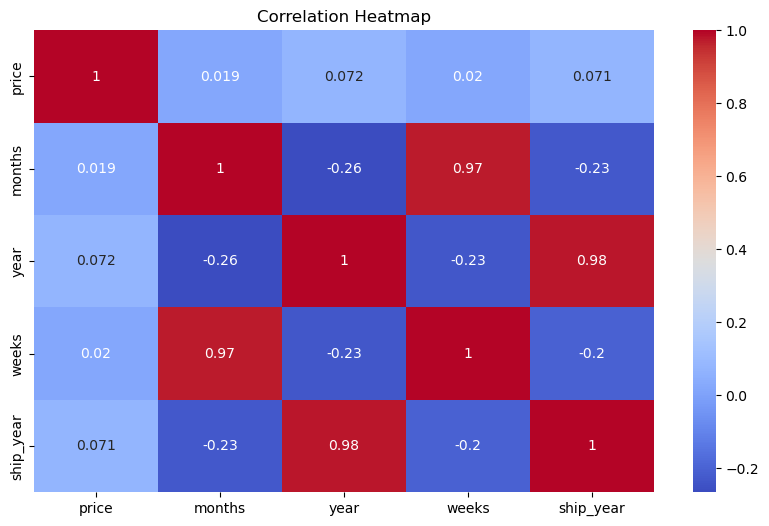

In [54]:
plt.figure(figsize=(10,6))
sns.heatmap(relation, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()